**Problem** **Statement**: **Online** **reviews** **contain** **valuable** **opinions** **that** **influence**
**consumer** **decisions**. **However**, **manually** **analyzing** **thousands** **of** **reviews** **is**
**time**-**consuming**. **A** **machine** **learning** **model** **is** **needed** **to** **automatically** **classify**
**text**-**based** **reviews** **as** **positive** **or** **negative** **based** **on** **sentiment**.

#step 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import tarfile

tar_path='/content/aclImdb_v1.tar.gz'
extract_path='/content/'

with tarfile.open(tar_path,'r') as tar:
  tar.extractall(extract_path)

/tmp/ipykernel_19384/2899488105.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


to check whether the file uploaded succesfully.

In [3]:
import os
os.listdir('/content')

['.config', 'aclImdb_v1.tar.gz', 'aclImdb', 'sample_data']

In [4]:
os.listdir('/content/aclImdb')

['imdb.vocab', 'imdbEr.txt', 'train', 'README', 'test']

reading text files from a folder and storing their contents in list

In [5]:
import os
import pandas as pd

def reviews_from_folder(folder_path,label):
  reviews=[]
  labels=[]

  for file_name in os.listdir(folder_path):
    file_path=os.path.join(folder_path,file_name)
    with open(file_path,'r',encoding='utf-8') as f:
      reviews.append(f.read())
      labels.append(label)
  return reviews,labels

In [6]:
train_pos='/content/aclImdb/train/pos'
train_neg='/content/aclImdb/train/neg'

test_pos='/content/aclImdb/test/pos'
test_neg='/content/aclImdb/test/neg'

read each file text,assign 1 for positive and 0 for negative

In [7]:
train_pos_reviews,train_pos_labels=reviews_from_folder(train_pos,1)
train_neg_reviews,train_neg_labels=reviews_from_folder(train_neg,0)

x_train=train_pos_reviews + train_neg_reviews
y_train=train_pos_labels + train_neg_labels

In [8]:
test_pos_reviews,test_pos_labels=reviews_from_folder(test_pos,1)
test_neg_reviews,test_neg_labels=reviews_from_folder(test_neg,0)

x_test=test_pos_reviews + test_neg_reviews
y_test=test_pos_labels + test_neg_labels

training Dataframe

In [9]:
train_df=pd.DataFrame({'review':x_train,'sentiment':y_train})

testing Dataframe

In [10]:
test_df=pd.DataFrame({'review':x_test,'sentiment':y_test})

top 5 rows of train_df,test_df

In [11]:
print(train_df.head())
print(test_df.head())

                                              review  sentiment
0  Man's Castle is set in one of those jerry buil...          1
1  This is one of the better comedies that has ev...          1
2  10 out of 10, this brilliant, super documentar...          1
3  this film was almost a great imaginative film....          1
4  Only after some contemplation did I decide I l...          1
                                              review  sentiment
0  Over the years, I've come to be a fan of direc...          1
1  This movie surprised me. The box is misleading...          1
2  Three children are born during a solar eclipse...          1
3  OK,so this film is NOT very well known,and was...          1
4  This movie is not for those expecting a martia...          1


In [12]:
print(train_df.shape)
print(test_df.shape)

(25000, 2)
(25000, 2)


In [13]:
print(train_df.isnull().sum(),test_df.isnull().sum())

review       0
sentiment    0
dtype: int64 review       0
sentiment    0
dtype: int64


#STEP 2

Importing libraries

In [14]:
import re
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [15]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words

In [16]:
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

Text preprocessing

In [17]:
def clean_text(text):
  text=text.lower()
  text=re.sub(r'<.*?>','',text)
  text=re.sub(r'[^a-z\s]','',text)
  words=word_tokenize(text)
  words=[
      lemmatizer.lemmatize(word)
      for word in words
      if word not in stop_words
  ]
  return ' '.join(words)

This line creates a new column where each review is cleaned using your clean_text function.

In [18]:
train_df['clean_review']=train_df['review'].apply(clean_text)

In [19]:
test_df['clean_review']=test_df['review'].apply(clean_text)

verifying and viewing the data

In [20]:
train_df[['review','clean_review']].head()

,review,clean_review
0,Man's Castle is set in one of those jerry buil...,man castle set one jerry built settlement vaca...
1,This is one of the better comedies that has ev...,one better comedy ever television season one h...
2,"10 out of 10, this brilliant, super documentar...",brilliant super documentary must see film clip...
3,this film was almost a great imaginative film....,film almost great imaginative film mixture sha...
4,Only after some contemplation did I decide I l...,contemplation decide liked movie reading comme...


#STEP 3

TF-IDF converts text into numerical vectors.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(max_features=6000,ngram_range=(1,2))
x_train=tfidf.fit_transform(train_df['clean_review'])
x_test=tfidf.transform(test_df['clean_review'])

y_train=train_df['sentiment']
y_test=test_df['sentiment']

In [22]:
print(x_train.shape)
print(x_test.shape)

(25000, 6000)
(25000, 6000)


#STEP 4

shuffling and creating a subset of data for polynomial,RBFSVM models

In [23]:
# from sklearn.utils import shuffle

# x_train_shuffled, y_train_shuffled = shuffle(x_train, y_train, random_state=4)

# train_subset = x_train.shape[0] // 2
# test_subset = x_test.shape[0] // 2

# x_train_half = x_train_shuffled[:train_subset]
# y_train_half = y_train_shuffled[:train_subset]

# x_test_half = x_test[:test_subset]
# y_test_half = y_test[:test_subset]

Training LinearSVC model

In [24]:
from sklearn.svm import LinearSVC
svm_model=LinearSVC(C=0.1)
svm_model.fit(x_train,y_test)
pred_y=svm_model.predict(x_test)

Training polynomialSVM

In [25]:
from sklearn.svm import SVC
polynomial=SVC(kernel='poly',degree=2,C=5)
polynomial.fit(x_train,y_train)
pred_y_polynomial=polynomial.predict(x_test)

Trainig RBFSVM

In [26]:
rbf_svm=SVC(kernel='rbf',C=5,gamma=0.05)
rbf_svm.fit(x_train,y_train)
pred_y_svm=rbf_svm.predict(x_test)

#STEP 5

For LinearSVC

In [27]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

train_acc = accuracy_score(y_train, pred_y)
test_acc = accuracy_score(y_test, pred_y)

print("Linear SVM Train Accuracy: {:.2f}%".format(train_acc * 100))
print("Linear SVM Test Accuracy: {:.2f}%".format(test_acc * 100))

print('\nconfusion matrix of linearSVM:')
print(confusion_matrix(y_test,pred_y))

print('\nclassification report of linearSVM:')
print(classification_report(y_test,pred_y))

Linear SVM Train Accuracy: 88.11%
Linear SVM Test Accuracy: 88.11%

confusion matrix of linearSVM:
[[10944  1556]
 [ 1416 11084]]

classification report of linearSVM:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     12500
           1       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



For polynomialSVM

In [28]:
train_acc = accuracy_score(y_train, pred_y_polynomial)
test_acc = accuracy_score(y_test, pred_y_polynomial)

print("Polynomial SVM Train Accuracy: {:.2f}%".format(train_acc * 100))
print("Polynomial SVM Test Accuracy: {:.2f}%".format(test_acc * 100))

print('\nconfusion matrix of polynomailSVM:')
print(confusion_matrix(y_test,pred_y_polynomial))

print('\nclassification report of polynomialSVM:')
print(classification_report(y_test,pred_y_polynomial))

Polynomial SVM Train Accuracy: 87.52%
Polynomial SVM Test Accuracy: 87.52%

confusion matrix of polynomailSVM:
[[10939  1561]
 [ 1559 10941]]

classification report of polynomialSVM:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



For RBFSVM

In [29]:
train_acc = accuracy_score(y_train, pred_y_svm)
test_acc = accuracy_score(y_test, pred_y_svm)

print("RBF SVM Train Accuracy: {:.2f}%".format(train_acc * 100))
print("RBF SVM Test Accuracy: {:.2f}%".format(test_acc * 100))

print('\nconfusion matrix of RBFSVM:')
print(confusion_matrix(y_test,pred_y_svm))

print('\nclassification report of RBFSVM:')
print(classification_report(y_test,pred_y_svm))

RBF SVM Train Accuracy: 87.95%
RBF SVM Test Accuracy: 87.95%

confusion matrix of RBFSVM:
[[10957  1543]
 [ 1470 11030]]

classification report of RBFSVM:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



logistic regression

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

log_model=LogisticRegression(max_iter=1000)
log_model.fit(x_train,y_train)

y_train_pred_log = log_model.predict(x_train)
y_test_pred_log = log_model.predict(x_test)

train_acc_log = accuracy_score(y_train, y_train_pred_log)
test_acc_log = accuracy_score(y_test, y_test_pred_log)

print("Train Accuracy of Logistic Regression:", train_acc_log*100)
print("Test Accuracy of Logistic Regression:", test_acc_log*100)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_log))

Train Accuracy of Logistic Regression: 91.604
Test Accuracy of Logistic Regression: 88.03999999999999

Confusion Matrix:
 [[10959  1541]
 [ 1449 11051]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



Plots

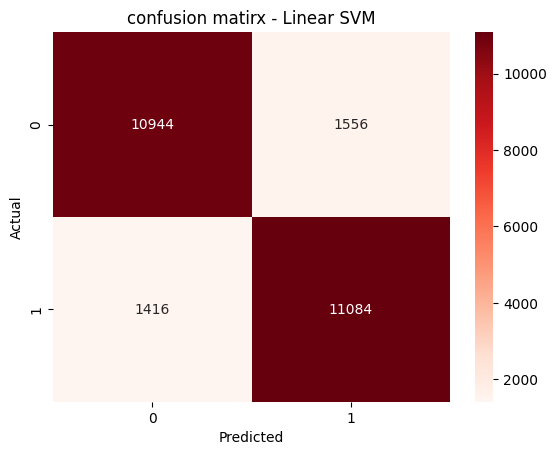

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,pred_y)
sns.heatmap(cm,annot=True,cmap='Reds',fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('confusion matirx - Linear SVM')
plt.show()

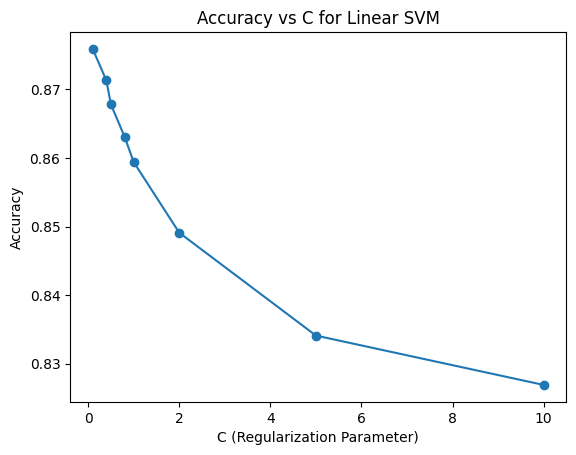

In [32]:
C_values = [0.1, 0.4, 0.5, 0.8, 1, 2, 5, 10]
accuracies = [0.8759, 0.8713, 0.8678, 0.8631, 0.8594, 0.8491, 0.8341, 0.8269]

plt.figure()
plt.plot(C_values, accuracies, marker='o')
plt.xlabel("C (Regularization Parameter)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs C for Linear SVM")
plt.show()

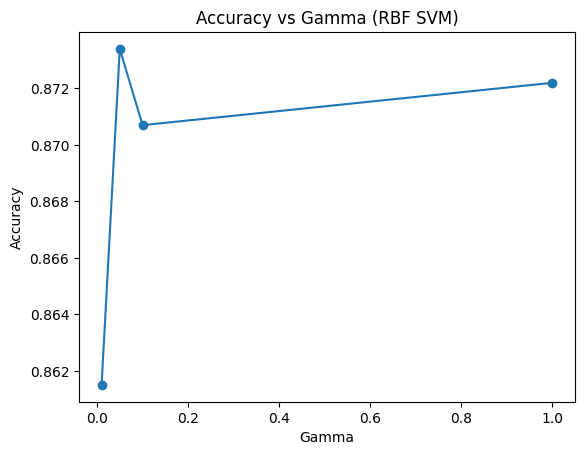

In [33]:
gamma_values = [0.01, 0.05, 0.1, 1]
accuracies = [0.8615, 0.8734, 0.8707, 0.8722]

plt.figure()
plt.plot(gamma_values, accuracies, marker='o')
plt.xlabel("Gamma")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Gamma (RBF SVM)")
plt.show()

#STEP 6 (OPTIMIZATION)


#The optimization was done to improve the performance of the SVM(support vector machince) models,the parameters considered were C,Gamma and max_features

#For LinearSVC diiferent values of C were evaluated,and observed that large c value leads to overfitting,so c=0.1 was selected for optimal value for LinearSVC

#For polynomial and RBFSVM,training on full dataset was computationally expensive,so a randomly shuffled subset of dataset was used.

#For RBGSVM the gamma value was optimized by keeping the C value fixed,and gamma=0.05 achieved the highest accuracy.


#Final Optimized Hyperparameters

#TF-IDF max_features: 6000
#Linear SVM: C = 0.1
#Polynomial SVM: C = 5
#RBF SVM: C = 5, gamma = 0.05

In [34]:
#The optimization was done to improve the performance of the SVM(support vector machince) models,the parameters considered were C,Gamma and max_features

#For LinearSVC diiferent values of C were evaluated,and observed that large c value leads to overfitting,so c=0.1 was selected for optimal value for LinearSVC

#For polynomial and RBFSVM,training on full dataset was computationally expensive,so a randomly shuffled subset of dataset was used.

#For RBGSVM the gamma value was optimized by keeping the C value fixed,and gamma=0.05 achieved the highest accuracy.


#Final Optimized Hyperparameters

#TF-IDF max_features: 6000
#Linear SVM: C = 0.1
#Polynomial SVM: C = 5
#RBF SVM: C = 5, gamma = 0.05